# 14 - 패널 데이터와 고정효과 (Panel Data and Fixed Effects)

In [19]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from matplotlib import style
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
import graphviz as gr
from linearmodels.datasets import wage_panel

%matplotlib inline
pd.set_option("display.max_columns", 15)
style.use("fivethirtyeight")

### DID에서 패널 데이터로

이전 챕터에서는 실험군·대조군(POA, FLN)과 딱 2개 기간(개입 전/후)만 있는 가장 단순한 DID를 다뤘습니다. 그런데 만약 기간이 3개, 5개, 10개로 늘어나고, 그룹도 2개가 아니라 3개, 10개, 100개가 된다면 어떻게 해야 할까요?

이렇게 **여러 기간에 걸쳐 동일한 대상(개인, 도시, 회사 등)을 반복적으로 관찰한 데이터**를 **패널 데이터(Panel Data)**라고 부릅니다. 정부의 정책 평가(여러 도시·주를 여러 해에 걸쳐 추적)나 기업의 유저 데이터 분석(같은 유저를 몇 주, 몇 달간 추적)에서 아주 흔하게 등장하는 구조예요.

패널 데이터를 다루는 도구가 바로 **고정효과(Fixed Effects)**입니다. 이번 챕터에서는 이전 챕터의 광고판 예시를 계속 이어가면서, DID의 아이디어가 패널 데이터에서 어떻게 일반화되는지 살펴볼게요.

### 지난 챕터 요약: DID의 counterfactual 대체 방법

이전 챕터에서 POA에 광고판을 세우지 않았다면 어떤 일이 일어났을지(counterfactual $Y_0$)를, **개입 전 POA의 값에 대조군(FLN)의 성장분을 더한 값**으로 추정했었죠.

$$
\underbrace{\widehat{Y_0(1)|D=1}}_{\substack{\text{POA outcome after intervention}} \\ \substack{\text{if no intervention had taken place}}}
= \underbrace{Y_0(0)|D=1}_{\substack{\text{POA outcome}} \\ \substack{\text{before intervention}}}
+ \big( \underbrace{Y_0(1)|D=0}_{\substack{\text{FLN outcome after}} \\ \substack{\text{intervention in POA}}}
- \underbrace{Y_0(0)|D=0}_{\substack{\text{FLN outcome before}} \\ \substack{\text{intervention in POA}}} \big)
$$

여기서 $t$는 시간, $D$는 처치를 나타내고, $Y_D(t)$는 "시간 $t$에, 처치 상태가 $D$일 때의 잠재적 결과"를 뜻합니다. 이 counterfactual을 대입하면 처치 효과(ATT)를 다음처럼 씁니다.

$$
\widehat{ATT} = \underbrace{Y_1(1)|D=1}_{\substack{\text{POA outcome} \\ \text{after intervention}}} - \widehat{Y_0(1)|D=1}
$$

즉, 광고판 효과는 "실제 관찰한 POA의 개입 후 결과"에서 "광고판이 없었다면 있었을 결과(추정치)"를 뺀 값이에요. 이 추정이 성립하려면 **POA의 예금 증가가 FLN의 예금 증가와 일치해야 한다**는 가정이 필요한데, 이게 바로 **평행 추세 가정(Parallel Trends Assumption)**입니다. 이번 챕터에서 이 가정을 더 정교하게 다뤄볼게요.

## 평행 추세 가정 (Parallel Trends)

평행 추세 가정을 이해하는 좋은 방법은, 앞서 배운 **독립성 가정(Independence Assumption)**과 비교해보는 것입니다. 독립성 가정은 처치 할당이 잠재적 결과와 독립적이어야 한다는 것이었죠.

$$Y_d \perp D$$

즉, "결과값이 원래 높거나 낮은 대상에게 처치를 더 많이/적게 주면 안 된다"는 뜻이에요. 예를 들어 마케팅 매니저가 **이미 예금이 많은 도시**에만 광고판을 세우기로 했다면, 나중에 "광고판 있는 도시가 예금이 더 많다"고 주장할 수는 있겠지만, 이건 광고 효과가 아니라 애초에 그 도시가 부유했기 때문일 뿐이에요. 이게 바로 독립성 가정 위반입니다.

교란변수 $X$를 조건으로 걸면, 이 가정은 **조건부 독립성 가정**으로 확장됩니다.

$$Y_d \perp D | X$$

### 왜 갑자기 "수준"이 아니라 "성장"을 이야기하나

여기서 논리가 한 단계 건너뛰는 부분이 있어서 짚어볼게요. 독립성 가정은 잠재적 결과의 **수준(level)** — 즉 "얼마나 높은 값인가" — 이 처치와 무관해야 한다고 말합니다. 반면 평행 추세 가정은 잠재적 결과의 시간에 따른 **성장(growth)** — 즉 "얼마나 빠르게 변하는가" — 이 처치와 무관해야 한다고 말해요. 왜 갑자기 "수준"에서 "성장"으로 바뀌었을까요?

이유는 DID가 원래 처리하려는 문제 자체가 다르기 때문입니다. DID는 두 그룹이 **원래부터 수준이 다를 수 있다**는 걸 이미 인정하고 시작해요(POA와 FLN이 원래 예금 수준이 달라도 됨). DID가 걱정하는 건 "그 수준이 시간이 지나면서 얼마나 변하는가"입니다. 그러니 DID의 핵심 가정도 자연스럽게 "수준이 같다"가 아니라 "변화하는 속도(성장)가 같다"가 되는 거예요. 이를 수식으로 쓰면:

$$\big(Y_d(t) - Y_d(t-1) \big) \perp D$$

말로 풀면: "**결과가 얼마나 증가하는지**를 기준으로 어느 대상에게 처치를 줄지 정하면 안 된다"는 것입니다.

이걸 광고판 예시에 대입해보면:
- **허용됨**: 원래 예금이 많은 도시에만 광고판을 세우는 것 (수준의 차이는 문제되지 않음)
- **금지됨**: 예금이 원래 가장 빠르게 늘고 있는 도시에만 광고판을 세우는 것 (성장의 차이가 처치와 얽히면 안 됨)

DID는 대조군의 추세를 그대로 실험군에 옮겨와서 counterfactual을 만든다는 걸 기억하면, 왜 "실험군과 대조군의 추세가 원래 달랐다면 이 가정이 깨진다"는 게 자연스럽게 이해될 거예요.

## 보이지 않는 것을 통제하기 (Controlling What You Cannot See)

성향점수, 선형회귀, 매칭 같은 방법들은 랜덤하지 않은 데이터의 교란변수를 통제하는 좋은 방법입니다. 하지만 이 방법들은 모두 **조건부 비교란성(conditional unconfoundedness)**이라는 중요한 가정에 의존해요.

$$(Y_0, Y_1) \perp T | X$$

풀어 말하면: 모든 교란변수를 **알고 있고, 측정할 수 있어야** 그것을 조건으로 걸어서 처치를 랜덤 배정처럼 취급할 수 있다는 뜻입니다. 문제는 교란변수를 항상 측정할 수 있는 건 아니라는 점이에요.

**예시**: 결혼이 남성의 수입에 미치는 영향을 알고 싶다고 해봅시다. 기혼 남성이 미혼 남성보다 평균적으로 더 많이 번다는 건 잘 알려진 사실이지만, 이게 인과관계인지는 불분명해요.

- 교육 수준이 높은 남성 → 결혼할 가능성도 높고, 수입도 높을 가능성이 높음 → 교육을 통제하면 해결
- 그런데 **외모(beauty)**도 마찬가지 역할을 할 수 있어요: 더 매력적인 사람이 결혼도 잘 하고, 보수 좋은 직업도 얻을 가능성이 높음
- 문제는 외모(또는 지능 같은 특성)는 **측정하기가 매우 어렵다**는 것

이렇게 측정되지 않은 교란변수가 있으면 편향(bias)이 생기고, 회귀분석으로는 해결할 수 없습니다. 도구변수(instrumental variable)를 쓰는 방법도 있지만, 좋은 도구변수를 찾는 건 결코 쉬운 일이 아니에요. 이번 챕터에서는 대신 **패널 데이터 구조**를 활용해서 이 문제를 풀어봅니다.

### 패널 데이터가 이 문제를 어떻게 푸는가

핵심 트릭은 이렇습니다: **같은 사람을 시간에 따라 반복 관찰하면, "그 사람에게 시간이 지나도 변하지 않는 모든 특성"은 자동으로 통제됩니다.**

아래 그래프는 4개 기간에 걸쳐 같은 사람을 추적하는 상황을 나타냅니다. 결혼(처치)과 소득(결과)은 시간에 따라 변하고, 결혼은 3, 4기에 발생(0→1)하며 같은 시기에 소득도 오릅니다. 반면 외모(측정 안 되는 교란변수)는 모든 기간에서 동일하다고 가정합니다 (몇 년 사이에 외모가 급격히 변하지는 않으니 합리적인 가정이에요).

![img](./data/img/fixed-effects/fe-graph.png)

**왜 "시간에 따라 고정된 값"이면 자동으로 통제가 될까요?** 직관적으로 생각해보면: 소득이 오른 이유가 "외모가 좋아져서"일 수는 없어요. 왜냐하면 같은 사람의 외모는 이 기간 동안 변하지 않았으니까요(가정상). 즉 외모라는 변수 자체를 측정하지 않아도, "이 사람의 외모는 항상 똑같다"는 사실만으로 그로 인한 편향의 가능성이 사라지는 겁니다.

이걸 다른 방식으로 표현하면, 시간에 고정된 교란변수를 **"그 사람만의 고유한 속성"**으로 보고, 인과그래프에 개인(unit)을 나타내는 중간 노드를 추가하는 것과 같습니다. 이제 그 개인 노드를 통제하면, 결과와 (관측되지 않은) 시간-고정 교란변수 사이의 backdoor path가 막힙니다.

![img](./data/img/fixed-effects/control-unit.png)

외모나 지능 같은 특성은 측정할 수 없지만, "이 사람은 시간이 지나도 같은 사람"이라는 사실은 알고 있습니다. 그래서 실제로 이를 통제하는 방법은 아주 간단해요: **각 사람을 나타내는 더미(dummy) 변수를 만들어 회귀 모델에 추가**하면 됩니다. 사람에 대한 더미변수를 추가하고 회귀를 돌리면, 회귀분석은 **"각 사람"을 고정한 상태에서** 결혼의 효과만 뽑아냅니다. 이렇게 대상(unit)에 대한 더미변수를 추가하는 방식을 **고정효과 모델(Fixed Effect Model)**이라고 부릅니다.

## 고정효과 (Fixed Effects)

문제를 조금 더 공식적으로 다뤄보기 위해, 데이터를 먼저 살펴볼게요. 결혼이 소득에 미치는 인과적 영향을 추정하는 것이 목표입니다. 데이터에는 여러 해에 걸쳐 여러 개인(`nr`)에 대한 `married`(기혼 여부)와 `lwage`(로그 변환한 소득)가 들어 있고, 그 외에도 근무 시간, 교육 연수 등의 변수가 있습니다.

In [20]:
data = wage_panel.load()
data.head()

,nr,year,black,exper,hisp,hours,married,educ,union,lwage,expersq,occupation
0,13,1980,0,1,0,2672,0,14,0,1.197540,1,9
1,13,1981,0,2,0,2320,0,14,1,1.853060,4,9
2,13,1982,0,3,0,2940,0,14,0,1.344462,9,9
3,13,1983,0,4,0,2960,0,14,0,1.433213,16,9
4,13,1984,0,5,0,3071,0,14,0,1.568125,25,5


### 고정효과 모델의 일반적인 형태

$$y_{it} = \beta X_{it} + \gamma U_i + e_{it}$$

- $y_{it}$: 시간 $t$에서 대상 $i$의 결과
- $X_{it}$: 시간 $t$에서 대상 $i$의 관측 가능한 변수 벡터 (예: 결혼, 경력)
- $U_i$: 대상 $i$에 대해 **관측할 수 없는** 변수 (외모, 지능 등). 시간이 지나도 변하지 않는다고 가정하므로 시간 첨자 $t$가 없습니다.
- $e_{it}$: 오차항

### "더미변수 추가"가 실제로는 왜 그렇게 안 되는가

앞서 "사람마다 더미변수를 추가하면 된다"고 했는데, 실제로는 이렇게 하지 않습니다. 이유는 단순해요: 고객이 백만 명이면 더미변수도 백만 개가 생기는데, 이건 계산적으로도 비효율적이고 다루기도 어렵습니다.

대신 **회귀분석을 2단계로 쪼개는 트릭**(Frisch–Waugh–Lovell 정리)을 사용합니다. 이 트릭이 왜 성립하는지 먼저 짚어볼게요. 변수 집합 $X_1$, $X_2$가 있는 회귀모델을 생각해봅시다.

$$\hat{Y} = \hat{\beta_1} X_1 + \hat{\beta_2} X_2$$

여기서 $\hat{\beta_1}$을 얻는 아래의 4단계 방식이, 위 모델을 한 번에 통째로 돌리는 것과 **정확히 같은 결과**를 줍니다.

1. $Y$를 $X_2$만으로 회귀: $\hat{y^*} = \hat{\gamma_1} X_2$
2. $X_1$을 $X_2$만으로 회귀: $\hat{X_1} = \hat{\gamma_2} X_2$
3. 각각의 **잔차(residual)**를 구하기: $\tilde{X}_1 = X_1 - \hat{X_1}$, $\tilde{y} = y - \hat{y^*}$
4. 잔차 $\tilde{y}$를 잔차 $\tilde{X}_1$에 회귀: $\hat{y} = \hat{\beta_1} \tilde{X}_1$

**잔차(residual)가 뭔지부터 짚으면**: 1, 2단계에서 구하는 건 "$X_2$로 설명이 되는 부분"이고, 잔차는 그걸 뺀 "$X_2$로는 설명이 안 되는 나머지"입니다. 즉 3단계를 거치면 $X_2$가 갖고 있던 정보는 $\tilde{X}_1$과 $\tilde{y}$ 양쪽에서 이미 걷어내진 상태예요.

간단한 예로, $X_2$가 "A반/B반" 더미라고 해봅시다. $\tilde{y}$는 "각 사람의 임금 − 자기 반의 평균 임금"이 되고, $\tilde{X}_1$은 "각 사람의 결혼 여부 − 자기 반의 평균 결혼율"이 됩니다. 반이 무엇이든 그 차이는 이미 평균으로 빠졌으니, 잔차 안에는 "반 정보"가 남아있지 않아요.

**왜 이게 통하는지 직관적으로 보면**: $X_2$의 정보가 양쪽에서 똑같이 빠졌기 때문에, 남은 잔차끼리의 관계는 $X_2$가 무엇이든 상관없는, $X_2$의 영향이 전혀 섞이지 않은 **순수한 $X_1 \to Y$의 관계**만 남습니다. (참고로 이 결과가 항상 정확히 성립한다는 게 Frisch-Waugh-Lovell 정리의 내용이고, 여기서는 증명 없이 결과만 가져다 씁니다.)

이걸 우리 문제에 적용하면: $X_2$ 자리에 "사람 더미변수 전체"를 넣는 겁니다. 그러면 1, 2단계는 "결과와 $X_1$에서, **사람별로 설명되는 부분**을 걷어내는 과정"이 됩니다.

여기서 마지막 퍼즐 조각 하나가 필요해요: **더미변수로 회귀하는 것은, 그 더미변수가 나타내는 그룹의 평균을 구하는 것과 완전히 같습니다.** 사람 더미변수라면, 한 사람은 자기 혼자만의 그룹이니 "그 그룹의 평균"은 그냥 "그 사람 개인의 평균"이 됩니다. 즉 1, 2단계에서 "사람 더미로 회귀해서 걷어내는 것"은 실제로는 "각자 자기 평균을 빼는 것"과 정확히 같은 계산이에요.

| 단계 | 이론상 필요한 것 | 실제로 하는 일 |
|---|---|---|
| 1, 2단계 | 백만 개의 사람 더미변수로 회귀 | 각 사람의 **평균**을 계산 |
| 3단계 | 잔차 구하기 | 각 값에서 그 사람의 **평균을 뺀 값** |

이 사실을 이용하면 백만 개의 더미변수를 실제로 만들 필요 없이, 그냥 "각 사람의 평균을 빼는" 것만으로 같은 효과를 얻을 수 있어요. 아래에서 이 사실("더미변수 회귀 = 그룹 평균")을 데이터로 직접 확인해봅시다.

### 더미변수 회귀 = 그룹 평균, 정말 같을까?

연도(year) 더미변수만으로 임금을 예측하는 모델을 돌려서 확인해봅니다.

In [5]:
mod = smf.ols("lwage ~ C(year)", data=data).fit()
mod.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1.3935,0.022,63.462,0.000,1.350,1.437
C(year)[T.1981],0.1194,0.031,3.845,0.000,0.059,0.180
C(year)[T.1982],0.1782,0.031,5.738,0.000,0.117,0.239
C(year)[T.1983],0.2258,0.031,7.271,0.000,0.165,0.287
C(year)[T.1984],0.2968,0.031,9.558,0.000,0.236,0.358
C(year)[T.1985],0.3459,0.031,11.140,0.000,0.285,0.407
C(year)[T.1986],0.4062,0.031,13.082,0.000,0.345,0.467
C(year)[T.1987],0.4730,0.031,15.232,0.000,0.412,0.534


이 회귀모델은 1980년의 평균 소득을 1.3935로, 1981년은 1.5129(=1.3935+0.1194)로 예측합니다. 기준연도인 1980년이 절편(intercept)이기 때문에, 다른 연도의 평균을 구하려면 절편값에 그 연도의 계수를 더해야 해요. 실제로 연도별 평균을 직접 계산해서 똑같은지 확인해봅시다.

In [6]:
data.groupby("year")["lwage"].mean()

year
1980    1.393477
1981    1.512867
1982    1.571667
1983    1.619263
1984    1.690295
1985    1.739410
1986    1.799719
1987    1.866479
Name: lwage, dtype: float64

정확히 일치합니다. 여기서는 "연도" 더미로 확인했지만, 같은 원리가 "사람" 더미에도 그대로 적용됩니다 — 더미변수가 무엇을 구분하는지(연도든 사람이든)는 상관없이, **더미변수로 회귀 = 그 더미가 나타내는 그룹별 평균을 구하는 것**이라는 사실 자체는 항상 성립하기 때문이에요.

즉, **패널 데이터에서 개인별 평균을 구하는 것은, 개인 더미변수로 회귀하는 것과 본질적으로 같은 일**입니다. 이 사실이 앞서 소개한 추정 절차의 근거가 됩니다.

다만 여기서 실제로 쓰는 건 평균 자체가 아니라 **평균과의 차이(잔차)**라는 점에 주의하세요. 평균만 남기면 사람마다 데이터가 한 줄로 뭉개져서, "그 사람 안에서 시간에 따라 결혼과 임금이 어떻게 같이 변했는지"라는 정보가 사라집니다. 그래서 각 시점의 값에서 그 사람의 평균을 **빼서** 시점별 데이터를 그대로 유지한 채, 사람마다 고정된 성분($U_i$)만 제거하는 거예요.

1. 개인별 평균을 빼서 **시간-차분(time-demeaned)** 변수 만들기:
   $\ddot{Y}_{it} = Y_{it} - \bar{Y}_i$, $\ddot{X}_{it} = X_{it} - \bar{X}_i$
2. $\ddot{Y}_{it}$를 $\ddot{X}_{it}$에 회귀

### 왜 평균을 빼면 $U_i$가 사라지는가

관측되지 않은 $U_i$는 시간에 따라 일정하다고 가정했으므로, 그 사람에 대한 평균을 구해도 값이 그대로입니다: $\bar{U}_i = U_i$. 이 사실이 핵심이에요. 원래 모델과, 그 모델을 개인별로 평균 낸 식을 나란히 놓아봅시다.

$$
\begin{align}
Y_{it} & = \beta X_{it} + \gamma U_i + e_{it} \\
\bar{Y}_{i} & = \beta \bar{X}_{it} + \gamma \bar{U}_i + \bar{e}_{it} \\
\end{align}
$$

위 식에서 아래 식을 빼면:

$$
\begin{align}
(Y_{it} - \bar{Y}_{i}) & = \beta(X_{it} - \bar{X}_{it}) + \gamma(U_i - \bar U_i) + (e_{it}-\bar{e}_{it}) \\
(Y_{it} - \bar{Y}_{i}) & = \beta(X_{it} - \bar{X}_{it}) + (e_{it}-\bar{e}_{it}) \qquad (\because U_i - \bar U_i = U_i - U_i = 0)\\
\ddot{Y}_{it} & = \beta \ddot{X}_{it} + \ddot{e}_{it} \\
\end{align}
$$

**직관적으로 다시 말하면**: 같은 사람의 값에서 그 사람의 평균을 빼면, "그 사람에게 항상 붙어있던 고정된 부분"은 정확히 0이 되어 사라집니다. $U_i$가 그 사람에게 늘 붙어있는 값이라서, 빼면 자기 자신을 빼는 셈이 되어 없어지는 거예요.

**주의할 점**: 이렇게 사라지는 건 $U_i$뿐만이 아니라, **시간에 따라 변하지 않는 모든 변수**입니다. 인종, 성별처럼 관측 가능하더라도 시간에 고정된 변수는 전부 함께 사라져요. 그래서 이런 변수들은 더미변수의 선형결합이 되어버려 모델에 넣을 수 없게 됩니다(다중공선성 문제로 모델이 실행되지 않아요).

![img](./data/img/fixed-effects/demeaned.png)

### 어떤 변수가 시간에 고정되어 있는지 확인하기

개인별로 데이터를 그룹화해서 표준편차의 합을 구하면, 값이 0인 변수는 그 사람 안에서는 전혀 변하지 않는 변수라는 뜻입니다.

In [7]:
data.groupby("nr").std().sum()

year            1334.971910
black              0.000000
exper           1334.971910
hisp               0.000000
hours         203098.215649
married          140.372801
educ               0.000000
union            106.512445
lwage            173.929670
expersq        17608.242825
occupation       739.222281
dtype: float64

표준편차 합이 0인 `black`, `hisp`, `educ`(인종·교육 변수)는 개인마다 시간이 지나도 변하지 않으므로 모델에서 제외해야 합니다. `occupation`(직업) 변수는 시간에 따라 변하긴 하지만, 결혼이 임금에 미치는 영향을 **매개(mediate)**할 수 있어서(미혼 남성이 시간이 더 많이 드는 직책을 맡을 수 있으므로) 이번 분석에서는 사용하지 않을게요.

이제 고정효과 모델을 돌리기 위해, 개인별 평균 데이터를 만들어봅시다.

In [8]:
Y = "lwage"
T = "married"
X = [T, "expersq", "union", "hours"]

mean_data = data.groupby("nr")[X+[Y]].mean()
mean_data.head()

,married,expersq,union,hours,lwage
nr,,,,,
13,0.000,25.5,0.125,2807.625,1.255652
17,0.000,61.5,0.000,2504.125,1.637786
18,1.000,61.5,0.000,2350.500,2.034387
45,0.125,35.5,0.250,2225.875,1.773664
110,0.500,77.5,0.125,2108.000,2.055129


평균을 빼는 작업(demeaning)을 하려면, 원본 데이터의 인덱스를 개인 식별자 `nr`로 맞춰야 합니다. 그런 다음 평균 데이터를 그냥 빼주면 됩니다.

In [9]:
demeaned_data = (data
               .set_index("nr") # set the index as the person indicator
               [X+[Y]]
               - mean_data) # subtract the mean data

demeaned_data.head()

,married,expersq,union,hours,lwage
nr,,,,,
13,0.0,-24.5,-0.125,-135.625,-0.058112
13,0.0,-21.5,0.875,-487.625,0.597408
13,0.0,-16.5,-0.125,132.375,0.088810
13,0.0,-9.5,-0.125,152.375,0.177561
13,0.0,-0.5,-0.125,263.375,0.312473


이렇게 평균을 뺀 데이터에 대해 고정효과 모델(회귀)을 돌릴 수 있습니다.

In [10]:
mod = smf.ols(f"{Y} ~ {'+'.join(X)}", data=demeaned_data).fit()
mod.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-6.418e-17,0.005,-1.26e-14,1.000,-0.010,0.010
married,0.1147,0.017,6.756,0.000,0.081,0.148
expersq,0.0040,0.000,21.958,0.000,0.004,0.004
union,0.0784,0.018,4.261,0.000,0.042,0.115
hours,-8.46e-05,1.25e-05,-6.744,0.000,-0.000,-6e-05


### 결과 해석과 표준오차 주의점

고정효과가 생략된 변수들의 편향을 제거해준다고 믿는다면, 이 모델은 **결혼이 남성의 임금을 11% 증가시킨다**고 말하고 있습니다.

한 가지 짚어야 할 세부사항: 고정효과 모델의 표준오차는 **클러스터링(clustered)**되어야 합니다. 같은 개인의 여러 시점 관측치는 서로 독립이 아니기 때문이에요. 직접 demean해서 회귀를 돌리는 방식은 원리를 이해하는 데는 좋지만(교육적 목적!), 실제로는 이런 세부사항을 자동으로 처리해주는 `linearmodels` 패키지의 `PanelOLS`를 사용하는 것이 좋습니다. `cluster_entity=True`로 설정하면 됩니다.

### 표준오차가 왜 달라지는가 — 클러스터링의 원리

demean한 데이터로 직접 회귀를 돌리든, `PanelOLS`를 쓰든, **계수(coefficient)와 잔차 값 자체는 완전히 똑같습니다.** 문제는 이 잔차들을 가지고 **표준오차를 계산하는 방식**이 다르다는 점이에요.

**1. 왜 잔차들이 서로 독립이 아닌가**

패널 데이터에서는 같은 사람(`nr`)의 여러 해 관측치가 그 사람 고유의 성향이나 흐름 때문에 서로 연관되어 있습니다. 예를 들어 어떤 사람이 원래 예측보다 항상 조금 높은 임금을 받는 경향이 있다면, 그 사람의 여러 해 잔차가 전부 비슷하게 양수 쪽으로 몰려있을 수 있어요. 즉 "같은 사람 안의 잔차들"은 무작위로 흩어진 게 아니라 서로 닮아 있습니다.

**2. 일반 OLS가 이를 무시하면 어떻게 되는가**

일반 OLS의 표준오차 공식은 오차가 서로 독립이라고 가정합니다.

$$\text{Var}(\hat\beta) = \sigma^2 (X'X)^{-1}$$

이 가정 아래에서는 관측치 개수만큼 "독립적인 정보"가 있다고 계산하는데, 실제로는 같은 사람 안의 관측치들이 서로 겹치는 정보라서 이보다 훨씬 적은 정보만 있는 셈입니다. 그래서 일반 OLS로 구한 표준오차는 실제보다 **더 작게(과소평가)** 나옵니다.

**3. 클러스터링이 하는 일**

클러스터-로버스트(cluster-robust) 표준오차는 아래처럼 공식을 바꿔서 계산합니다 ("샌드위치 추정량").

$$\text{Var}_{\text{cluster}}(\hat\beta) = (X'X)^{-1} \left[ \sum_{g} X_g' \, u_g u_g' \, X_g \right] (X'X)^{-1}$$

여기서 $g$는 클러스터(=사람 한 명), $u_g$는 그 사람의 여러 시점 잔차를 모은 벡터입니다. 핵심은 $u_g u_g'$ 부분인데, 이 행렬의 대각선 밖(off-diagonal) 원소들이 "같은 사람의 잔차들끼리 얼마나 같은 방향으로 움직이는지"를 계산해줍니다. 이 값이 크면(즉 상관이 강하면) 분산도 커지고, 결과적으로 표준오차도 더 크게(더 정직하게) 나옵니다.

**4. `PanelOLS`는 이걸 어떻게 적용하는가**

```python
from linearmodels.panel import PanelOLS
mod = PanelOLS.from_formula("lwage ~ expersq+union+married+hours+EntityEffects",
                            data=data.set_index(["nr", "year"]))
result = mod.fit(cov_type='clustered', cluster_entity=True)
```

- `EntityEffects`: 사람(`nr`)별로 demean해서 고정효과를 제거 — 계수 계산은 손으로 한 것과 동일
- `cluster_entity=True`: "같은 `nr`을 가진 관측치들은 하나의 클러스터"라고 지정
- `cov_type='clustered'`: 클러스터 안에서는 잔차의 상관을 허용하고, 클러스터 사이(다른 사람들 간)에서는 독립이라고 가정한 채 위의 샌드위치 공식으로 분산을 다시 계산

즉 클러스터링은 "어떤 변수를 고정한다"는 의미가 아니라, **"어느 관측치 묶음 안에서는 상관을 있는 그대로 인정하고 계산하겠다"**는 뜻입니다. 그래서 계수는 demean+OLS와 정확히 같고, 표준오차만 (더 정확하게) 커지는 거예요.

In [11]:
from linearmodels.panel import PanelOLS
mod = PanelOLS.from_formula("lwage ~ expersq+union+married+hours+EntityEffects",
                            data=data.set_index(["nr", "year"]))

result = mod.fit(cov_type='clustered', cluster_entity=True)
result.summary.tables[1]

,Parameter,Std. Err.,T-stat,P-value,Lower CI,Upper CI
expersq,0.0040,0.0002,16.552,0.0000,0.0035,0.0044
union,0.0784,0.0236,3.3225,0.0009,0.0322,0.1247
married,0.1147,0.0220,5.2213,0.0000,0.0716,0.1577
hours,-8.46e-05,2.22e-05,-3.8105,0.0001,-0.0001,-4.107e-05


파라미터 추정치가 앞서 손으로 demean해서 얻은 것과 동일한지 확인해보세요. 유일한 차이는 표준오차가 조금 더 크다는 점입니다(클러스터링을 제대로 반영했기 때문).

이제 비교를 위해, 시간 구조를 전혀 고려하지 않은 **단순 OLS 모델**을 돌려봅니다. 이 경우엔 앞서 제외했던 시간-고정 변수들(`black`, `hisp`, `educ`)을 다시 넣어야 해요.

In [12]:
mod = smf.ols("lwage ~ expersq+union+married+hours+black+hisp+educ", data=data).fit()
mod.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.2654,0.065,4.103,0.000,0.139,0.392
expersq,0.0032,0.000,15.750,0.000,0.003,0.004
union,0.1829,0.017,10.598,0.000,0.149,0.217
married,0.1410,0.016,8.931,0.000,0.110,0.172
hours,-5.32e-05,1.34e-05,-3.978,0.000,-7.94e-05,-2.7e-05
black,-0.1347,0.024,-5.679,0.000,-0.181,-0.088
hisp,0.0132,0.021,0.632,0.528,-0.028,0.054
educ,0.1057,0.005,22.550,0.000,0.097,0.115


### 왜 단순 OLS의 효과가 더 크게 나오는가

이 모델은 결혼이 남성의 임금을 **14%** 증가시킨다고 말합니다. 고정효과 모델(11%)보다 더 큰 값이에요.

이 차이가 바로 **생략변수 편향(omitted variable bias)**입니다. 단순 OLS는 지능이나 외모처럼 **측정되지 않는, 개인마다 고정된 요인들**을 전혀 통제하지 못해요. 만약 이런 요인들이 결혼 가능성과 임금 모두에 긍정적인 영향을 준다면(매력적이고 능력 있는 사람이 결혼도 잘 하고 돈도 잘 번다면), 단순 OLS는 그 효과까지 "결혼의 효과"로 착각해서 실제보다 부풀린 값을 내놓습니다. 고정효과 모델은 바로 이 부분을 제거해준 것이고요.

3%p 차이는 개인 고정효과(생략된 변수)가 결혼·임금 둘 다에 같은 방향으로 영향을 주면서 생긴 편향의 크기

## 고정효과 시각화하기 (Visualizing Fixed Effects)

고정효과가 실제로 어떤 일을 하는지 직관을 키우기 위해 다른 예시를 살펴볼게요. 여러분이 IT 대기업에서 일하며, 광고판 캠페인이 인앱 구매에 미치는 영향을 추정한다고 해봅시다.

과거 데이터를 보니, 마케팅 부서는 **구매 수준이 낮은 도시**에 더 많은 마케팅 비용을 쓰는 경향이 있었습니다. 사실 합리적인 전략이죠 — 이미 매출이 잘 나오는 도시에 광고를 더 쏟을 필요는 없으니까요. 하지만 이 데이터로 단순 회귀를 돌리면, "마케팅 비용이 높을수록 인앱 구매가 줄어드는" 것처럼 보이는 이상한 결과가 나옵니다. 이건 마케팅 효과가 실제로 마이너스라서가 아니라, **애초에 마케팅 투자가 성과가 낮은 도시에 집중**되어 있었기 때문이에요.

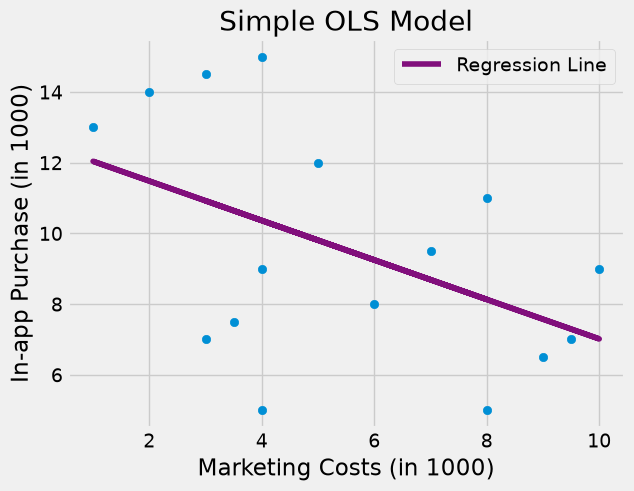

In [13]:
toy_panel = pd.DataFrame({
    "mkt_costs":[5,4,3.5,3, 10,9.5,9,8, 4,3,2,1, 8,7,6,4],
    "purchase":[12,9,7.5,7, 9,7,6.5,5, 15,14.5,14,13, 11,9.5,8,5],
    "city":["C0","C0","C0","C0", "C2","C2","C2","C2", "C1","C1","C1","C1", "C3","C3","C3","C3"]
})

m = smf.ols("purchase ~ mkt_costs", data=toy_panel).fit()

plt.scatter(toy_panel.mkt_costs, toy_panel.purchase)
plt.plot(toy_panel.mkt_costs, m.fittedvalues, c="C5", label="Regression Line")
plt.xlabel("Marketing Costs (in 1000)")
plt.ylabel("In-app Purchase (in 1000)")
plt.title("Simple OLS Model")
plt.legend();

이제 고정효과 모델을 돌려서, 도시를 나타내는 더미변수를 추가해봅시다. 고정효과 모델은 **시간에 따라 일정한 도시 고유의 특성**(예: 이 도시는 원래 우리 제품에 덜 관심이 있다)을 통제해줍니다. 이 모델을 돌리면, 이번에는 "마케팅 비용이 늘면 인앱 구매도 늘어난다"는, 기대했던 방향의 결과를 확인할 수 있어요.

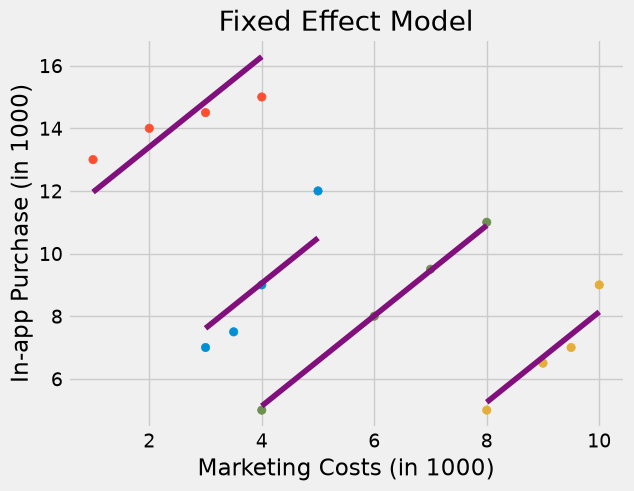

In [14]:
fe = smf.ols("purchase ~ mkt_costs + C(city)", data=toy_panel).fit()

fe_toy = toy_panel.assign(y_hat = fe.fittedvalues)

plt.scatter(toy_panel.mkt_costs, toy_panel.purchase, c=toy_panel.city)
for city in fe_toy["city"].unique():
    plot_df = fe_toy.query(f"city=='{city}'")
    plt.plot(plot_df.mkt_costs, plot_df.y_hat, c="C5")

plt.title("Fixed Effect Model")
plt.xlabel("Marketing Costs (in 1000)")
plt.ylabel("In-app Purchase (in 1000)");

### 그래프가 보여주는 것

그림을 잘 보면, 고정효과 모델은 **도시마다 하나씩, 서로 평행한 회귀선**을 적합시킵니다. 각 선의 기울기가 "마케팅 비용이 인앱 구매에 미치는 효과"인데, 모든 도시에서 이 기울기가 **동일**하다는 점에 주목하세요.

이게 바로 고정효과 모델의 가정입니다: **인과 효과가 모든 개체(여기서는 도시)에 걸쳐 동일하다**고 가정하는 것. 이 가정은 관점에 따라 장점일 수도, 단점일 수도 있어요.

- 만약 **도시별로 다른 효과**를 알고 싶다면 → 단점 (고정효과 모델은 도시 간 효과 차이를 잡아내지 못함)
- 만약 **전반적인 평균 효과**만 알고 싶다면 → 장점 (패널 구조를 활용해 편향 없이 그 하나의 효과를 잘 추정해줌)

## 시간 효과 (Time Effects)

개인(entity) 수준에서 고정효과를 만든 것처럼, **시간(time)** 수준에서도 고정효과를 만들 수 있습니다. 개인 더미변수가 "그 사람에게 항상 고정된 특성"을 통제해주는 것처럼, 시간 더미변수는 "그 시점에 모든 대상에게 공통으로 적용되는, 시간에 따라 변하는 요인"을 통제해줍니다.

**예시**: 인플레이션. 물가와 임금은 시간이 지나면서 대체로 오르는데, 특정 시점의 인플레이션 수준은 그 시점의 **모든 사람에게 동일하게** 적용됩니다.

이걸 우리 예시에 적용해보면: 만약 결혼 비율도 시간이 지나며 증가하고, 임금도 인플레이션 때문에 시간이 지나며 증가한다면 — 결혼과 임금 사이에 보이는 양의 관계가 사실은 **둘 다 그냥 시간이 지나면서 같이 올랐을 뿐**일 수도 있어요. 즉 "시간"이라는 요인 자체가 교란변수가 될 수 있습니다.

이걸 보정하려면 각 기간에 대한 더미변수를 추가하면 됩니다. `linearmodels` 패키지에서는 수식에 `TimeEffects`를 추가하고 `cluster_time=True`로 설정하면 간단히 처리됩니다.

In [15]:
mod = PanelOLS.from_formula("lwage ~ expersq+union+married+hours+EntityEffects+TimeEffects",
                            data=data.set_index(["nr", "year"]))

result = mod.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
result.summary.tables[1]

,Parameter,Std. Err.,T-stat,P-value,Lower CI,Upper CI
expersq,-0.0062,0.0008,-8.1479,0.0000,-0.0077,-0.0047
union,0.0727,0.0228,3.1858,0.0015,0.0279,0.1174
married,0.0476,0.0177,2.6906,0.0072,0.0129,0.0823
hours,-0.0001,3.546e-05,-3.8258,0.0001,-0.0002,-6.614e-05


시간 효과까지 통제한 새 모델에서는, 결혼이 임금에 미치는 영향이 **0.1147 → 0.0476**으로 크게 줄었습니다. 그래도 99% 신뢰수준에서 여전히 유의미한 값이라, 결혼이 임금에 실제로 어느 정도 양(+)의 효과를 준다고 볼 수 있어요.

### 최종 정리 - 패널데이터 회귀에서 고정효과와 시간효과를 고려해야 하는 이유

**1. 왜 일반 OLS로는 부족한가**

패널데이터를 그냥 일반 OLS로 회귀하면 두 가지 문제가 동시에 생깁니다.

- **표준오차 왜곡**: 같은 클러스터(개인)의 여러 시점 관측치는 서로 독립이 아닌데, 일반 OLS는 이를 독립이라고 가정하고 계산합니다.
- **계수 왜곡(생략변수 편향)**: 클러스터에 고정된 교란요인, 시점에 공통된 교란요인이 회귀계수에 그대로 섞여 들어갑니다.

이 둘은 서로 다른 문제이고, 아래처럼 서로 다른 해결책으로 대응합니다.

| 이슈 | 원인 | 해결책 |
|---|---|---|
| 계수가 편향됨 | 클러스터별 고정 교란요인, 시점별 공통 교란요인이 계수에 섞임 | `EntityEffects`, `TimeEffects` (demean) |
| 표준오차가 왜곡됨 | 같은 클러스터/시점 안 관측치들이 서로 독립이 아님 | `cluster_entity`, `cluster_time` |

**2. 고정효과(Entity Effects)란**

그 클러스터(여기서는 개인)가 가진 고유한 특징으로, 시간이 지나도 변하지 않는 특성입니다 (예: 외모, 지능).

**3. 왜 잔차(demean)로 제거되는가**

각 값에서 그 클러스터의 평균을 빼주면($Y_{it} - \bar Y_i$), 그 클러스터가 가진 고유한 특징(시간에 따라 변하지 않는 값)은 자기 자신을 빼는 셈이 되어 사라지고, **시간에 따른 변화량만** 남습니다. 이 과정을 통해 고정효과를 제거할 수 있습니다.

**4. PanelOLS에서의 적용**

이는 `PanelOLS`에서 `EntityEffects` 파라미터를 추가함으로써 간단히 구현됩니다. 이때 역할이 두 단계로 나뉩니다.

- `EntityEffects` (demean): 개인 고유 특성을 제거해서 **계수를 올바르게** 만듦 — 손으로 demean한 것과 회귀계수가 동일
- `cov_type='clustered', cluster_entity=True`: 같은 개인 안 관측치들의 상관을 반영해서 **표준오차를 올바르게 키움**

즉 "회귀계수 자체는 달라지지 않지만, 분산(표준오차)이 커지는 효과"는 `EntityEffects`가 아니라 그 뒤에 붙는 클러스터링 옵션의 역할입니다.

**5. 시간효과(Time Effects)란**

시점이 바뀌면서 모든 클러스터(개인)에게 공통적으로 영향을 주는 요인입니다.

**6. 예시**

- 인플레이션 효과: 시간이 지나며 모두의 임금이 자연스럽게 오름
- 결혼 비율 증가: 시간이 지나며 사회적으로 결혼 비율도 자연스럽게 오름

**7. 왜 이게 문제가 되는가**

결혼 비율과 임금이 각자 독립적으로 그냥 시간이 지나며 같이 오르는 추세가 있을 뿐인데, 이 둘을 나란히 놓고 보면 마치 "결혼이 임금을 올린다"는 인과관계처럼 보일 수 있습니다. 이는 결혼과 임금 사이에 실제 인과관계가 없어도(둘 다 그냥 시간에 따라 증가하는 추세만 있어도) 발생할 수 있는 **시간이라는 공통 요인 때문에 생기는 가짜 상관(spurious correlation)** 입니다.

**8. 시간효과 제거 방법**

이를 제거하려면 `PanelOLS`에 `TimeEffects` 파라미터를 추가하면 됩니다. 개인 고정효과와 시간 고정효과를 동시에 반영할 때는 다음과 같은 이중 demean 공식을 사용합니다.

$$\ddot Y_{it} = Y_{it} - \bar Y_i - \bar Y_t + \bar Y$$

- $\bar Y_i$: 그 개인의 평균을 빼서 → 개인 고정효과 제거
- $\bar Y_t$: 그 시점의 평균을 빼서 → 시간 고정효과 제거
- $+\bar Y$: 전체 평균을 다시 더해줌 → 두 평균을 각각 빼면 전체 평균이 이중으로 차감되므로, 이를 보정하기 위해 다시 더해주는 것

**9. 결론**

패널데이터에서 클러스터에 고정된 교란요인(고정효과)과 시간에 공통된 교란요인(시간효과)을 둘 다 제거해야, 결혼-임금 관계에서 다른 요인이 섞이지 않은 순수한 효과를 볼 수 있습니다. 이렇게 구해진 회귀계수라야 비로소 인과적인 수치로 해석할 수 있습니다.

## 패널 데이터로도 해결 안 되는 경우 (When Panel Data Won't Help You)

패널 데이터와 고정효과는 인과추론에 매우 강력한 도구입니다. 무작위 실험이 불가능한 상황에서 비실험 데이터(non-experimental data)로 인과관계를 추정할 때, 이만큼 설득력 있는 방법도 흔치 않아요. 그렇다고 만병통치약은 아닙니다. 고정효과가 통하지 않는 대표적인 두 가지 상황을 짚어볼게요.

### 상황 1 — 시간에 따라 변하는 교란변수

고정효과가 제거할 수 있는 건 **"각 대상에게 시간이 지나도 변하지 않는" 편향**뿐입니다. 만약 교란변수가 시간에 따라 변한다면, 고정효과로는 제거되지 않습니다.

**예시**: "많은 책을 읽고 좋은 지방을 섭취하면 지능이 올라간다"고 가정해봅시다. 지능이 올라가면 고소득 직업을 얻거나 배우자를 만날 가능성도 높아질 수 있어요. 이 경우 지능은 결혼-임금 관계의 교란변수인데, **지능 자체가 시간에 따라 변하기 때문에** 고정효과로는 이 편향을 없앨 수 없습니다. (앞서 demean 과정에서 배웠듯, 고정효과는 오직 "그 사람에게 항상 똑같이 붙어있는 값"만 제거할 수 있으니까요.)

![img](./data/img/fixed-effects/time-travel.png)

### 상황 2 — 역인과관계 (Reverse Causality)

고정효과가 실패하는 또 다른 대표적인 경우는 **역인과관계**가 있을 때입니다.

**예시**: 만약 실제 인과관계의 방향이 "결혼 → 임금 증가"가 아니라, 정반대로 "**돈을 더 많이 벌수록 결혼할 확률이 높아진다**"라면 어떨까요? 데이터에서는 여전히 결혼과 임금 사이에 양의 관계가 보이지만, 사실은 임금이 원인이고 결혼이 결과인 상황이에요.

이 경우 두 변수는 **시간이 지나며 같은 방향으로 함께 변합니다**. 그런데 고정효과는 각 개인 안에서의 변화(within-variation)를 보는 방법이기 때문에, 애초에 "무엇이 원인이고 무엇이 결과인지"를 구분해주는 장치가 아니에요. 그래서 이런 역인과관계 상황을 고정효과만으로는 통제할 수 없습니다.

## 핵심 정리 (Key Ideas)

이번 챕터에서는 여러 기간에 걸쳐 동일한 대상을 반복 관찰한 **패널 데이터**를 다루는 방법을 살펴봤습니다.

- 대상(entity)에 대한 고정효과를 사용하면, **시간에 따라 변하지 않는 모든 변수**(측정되지 않은 것 포함)를 자동으로 통제할 수 있습니다.
- 이 방법은 백만 개의 더미변수를 실제로 만드는 대신, **개인별 평균을 빼는(demeaning)** 방식으로 효율적으로 구현할 수 있습니다.
- 고정효과 모델은 비실험 데이터로 교란변수를 통제하는 매우 강력하고 설득력 있는 방법입니다.
- 하지만 만병통치약은 아닙니다: **시간에 따라 변하는 교란변수**나 **역인과관계**가 있는 경우에는 고정효과만으로 문제를 해결할 수 없습니다.

## 참고 자료

이 책을 쓰기 위해 Joshua Angrist, Alberto Abadie, Christopher Walters의 대단한 계량 경제학 수업 자료를 많이 참고했습니다. 해당 자료에 있는 대부분의 아이디어는 전미경제학회(American Economic Association)의 수업에서 가져왔어요.

* [Cross-Section Econometrics](https://www.aeaweb.org/conference/cont-ed/2017-webcasts)
* [Mastering Mostly Harmless Econometrics](https://www.aeaweb.org/conference/cont-ed/2020-webcasts)

또한, Angrist의 좋은 책들도 참고자료로 추천합니다.

* [Mostly Harmless Econometrics](https://www.mostlyharmlesseconometrics.com/)
* [Mastering 'Metrics](https://www.masteringmetrics.com/)

Miguel Hernan과 Jamie Robins의 책도 큰 도움이 되었습니다.

* [Causal Inference Book](https://www.hsph.harvard.edu/miguel-hernan/causal-inference-book/)

Scott Cunningham의 Mixtape 자료에도 감사를 전합니다.

* [Causal Inference: The Mixtape](https://www.scunning.com/mixtape.html)

![img](./data/img/poetry.png)

## 기여하기 (Contribute)

Causal Inference for the Brave and True는 인과추론·통계학에 대한 오픈소스 자료입니다. 금전적으로 지원하고 싶으시다면 [Patreon](https://www.patreon.com/causal_inference_for_the_brave_and_true)을 방문해주세요. 오타 수정이나 피드백은 [Github 이슈 페이지](https://github.com/CausalInferenceLab/Causal-Inference-with-Python/issues)에서 남길 수 있습니다. 도움이 되셨다면 [한국어 번역 자료](https://github.com/CausalInferenceLab/Causal-Inference-with-Python/stargazers)와 [원서 저장소](https://github.com/matheusfacure/python-causality-handbook/stargazers)에 star를 부탁드립니다!